# Потоковая обработка данных: Kafka, Lambda/Kappa, batch vs real-time

Обе прошлые лекции были **batch**-ориентированными: [DWH/Data Lake/Lakehouse/Data Mesh](1.ipynb)
и [Airflow-пайплайны с watermark-инкрементальной загрузкой](2.ipynb) — везде данные приезжают
**порциями**, по расписанию. Это закрывает большую часть реальных задач, но не отвечает на
вопрос: а как данные вообще **непрерывно** попадают в Data Lake/DWH, если источник — не таблица
с `updated_at`, а поток кликов на сайте, показаний датчиков или платёжных событий?

Это не просто "новый инструмент вместо Airflow" — это **другая ментальная модель**:

| | Batch (лекции 1-2) | Streaming (эта лекция) |
|---|---|---|
| Данные | Ограниченный набор (bounded) | Бесконечный поток (unbounded) |
| Модель доступа | Pull — пайплайн сам приходит за данными по расписанию | Push — данные сами прилетают, когда происходят |
| Задержка (latency) | Минуты-часы (по расписанию) | Секунды-миллисекунды |
| "Когда данные точно все" | Понятно: после `SELECT` всё сразу видно | Никогда не понятно — поток не заканчивается |
| Повторный запуск | Естественная идемпотентность через watermark | Нужны отдельные гарантии доставки |
| Типичные инструменты | Airflow, dbt, DWH/Lakehouse | Kafka, Flink, Kafka Streams |

План лекции:

1. Apache Kafka: топики, партиции, offset'ы, consumer group'ы
2. Гарантии упорядочивания и выбор ключа партиционирования
3. Семантика доставки: at-most-once / at-least-once / exactly-once
4. Event time vs processing time: окна и watermark в потоковой обработке
5. От потока к витрине: sink в Postgres
6. CDC (Change Data Capture): как в проде получают потоки без polling
7. Lambda Architecture
8. Kappa Architecture
9. Инструменты в реальном мире
10. Batch vs Streaming: как выбирать
11. Важные выводы
12. Задания для практики

Практика работает с **настоящим Kafka-совместимым брокером** — [Redpanda](https://redpanda.com/)
в Docker (контейнер `tutor-redpanda`, `localhost:9092`; API полностью совместим с Kafka, но
без Zookeeper и с гораздо более быстрым стартом — удобно для учебного контейнера). Клиент —
`kafka-python`. Раздел 5 пишет результат в ту же Postgres-базу `pipelines`, что и в
[лекции про Airflow](2.ipynb) — замыкаем цепочку "поток → витрина" на уже знакомую инфраструктуру.

## Подключение

Каждый прогон ноутбука использует **свежий `RUN_ID`** для consumer group'ов и заново
пересоздаёт топики — иначе повторный запуск ноутбука подхватил бы закоммиченные offset'ы
из прошлого прогона и демонстрации перестали бы быть детерминированными (та же идея, что и
`shutil.rmtree` для лога версий в лекции 1, и `DROP TABLE` в лекции 2 — чистый старт при
каждом запуске).

In [1]:
import json
import time
import uuid
import random
from datetime import datetime, timedelta

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

from kafka import KafkaProducer, KafkaConsumer, TopicPartition, OffsetAndMetadata
from kafka.admin import KafkaAdminClient, NewTopic

random.seed(42)
RUN_ID = uuid.uuid4().hex[:8]
BOOTSTRAP = "127.0.0.1:9092"

admin = KafkaAdminClient(bootstrap_servers=BOOTSTRAP)


def reset_topic(name: str, partitions: int = 1) -> None:
    """Удаляет топик (если есть) и создаёт заново — чистый слейт для каждого запуска ноутбука."""
    try:
        admin.delete_topics([name])
    except Exception:
        pass
    for _ in range(30):
        try:
            admin.create_topics([NewTopic(name=name, num_partitions=partitions, replication_factor=1)])
            return
        except Exception:
            time.sleep(0.3)
    raise RuntimeError(f"Не удалось пересоздать топик {name}")


def draw_box(ax, x, y, w, h, text, facecolor="#dbe9ff", edgecolor="#2b6cb0", fontsize=9.5):
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.08",
                          linewidth=1.6, edgecolor=edgecolor, facecolor=facecolor)
    ax.add_patch(box)
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fontsize)


def draw_arrow(ax, start, end, color="#4a5568"):
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=14,
                                  linewidth=1.5, color=color))


print(f"RUN_ID = {RUN_ID}")
print("Kafka-совместимый брокер:", BOOTSTRAP)

RUN_ID = 177c11e9
Kafka-совместимый брокер: 127.0.0.1:9092


## 1. Apache Kafka: топики, партиции, offset'ы, consumer group'ы

* **Топик (topic)** — именованный поток событий, например `orders_events`. Логически это
  "таблица", но данные в ней не обновляются и не удаляются — только дописываются (append-only log).
* **Партиция (partition)** — топик физически разбит на несколько партиций, каждая — это
  независимый **упорядоченный** лог. Партиционирование — то, что даёт Kafka горизонтальное
  масштабирование: разные партиции можно писать/читать параллельно.
* **Offset** — порядковый номер сообщения внутри партиции (не внутри топика целиком!).
  Consumer запоминает не "какие сообщения он прочитал", а "до какого offset'а в каждой партиции
  он дошёл".
* **Consumer group** — несколько consumer'ов, которые вместе читают один топик, разделив между
  собой партиции (каждая партиция закреплена ровно за одним consumer'ом внутри группы
  одновременно). Это единица горизонтального масштабирования на чтение.

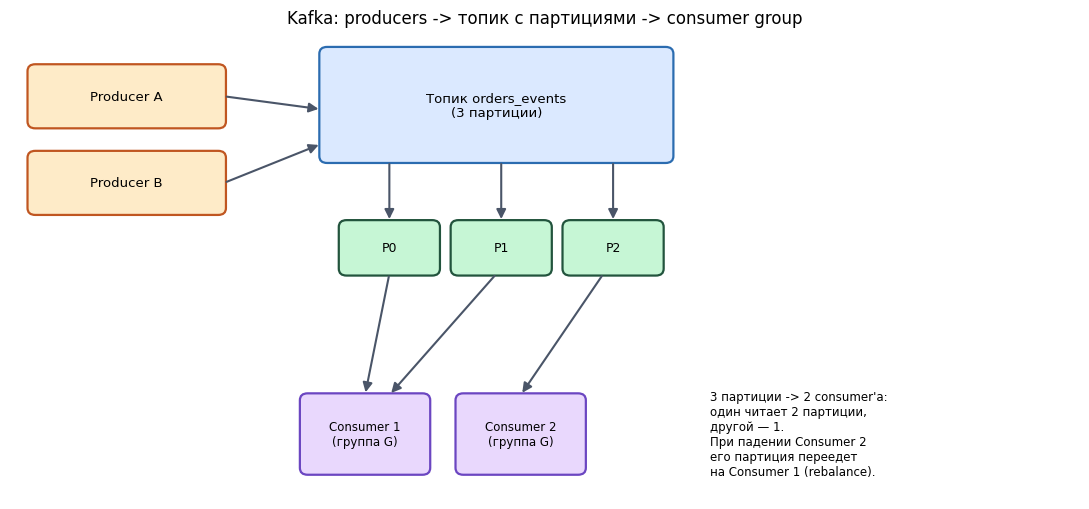

In [2]:
fig, ax = plt.subplots(figsize=(11, 5.2))
ax.set_xlim(0, 11)
ax.set_ylim(0, 5.4)
ax.axis("off")

draw_box(ax, 0.2, 4.3, 2.0, 0.7, "Producer A", facecolor="#feebc8", edgecolor="#c05621")
draw_box(ax, 0.2, 3.3, 2.0, 0.7, "Producer B", facecolor="#feebc8", edgecolor="#c05621")

draw_box(ax, 3.2, 3.9, 3.6, 1.3, "Топик orders_events\n(3 партиции)", facecolor="#dbe9ff", edgecolor="#2b6cb0")
draw_arrow(ax, (2.2, 4.65), (3.2, 4.5))
draw_arrow(ax, (2.2, 3.65), (3.2, 4.1))

for i in range(3):
    draw_box(ax, 3.4 + i * 1.15, 2.6, 1.0, 0.6, f"P{i}", facecolor="#c6f6d5", edgecolor="#22543d", fontsize=9)
    draw_arrow(ax, (3.9 + i * 1.15, 3.9), (3.9 + i * 1.15, 3.2))

draw_box(ax, 3.0, 0.3, 1.3, 0.9, "Consumer 1\n(группа G)", facecolor="#e9d8fd", edgecolor="#6b46c1", fontsize=8.5)
draw_box(ax, 4.6, 0.3, 1.3, 0.9, "Consumer 2\n(группа G)", facecolor="#e9d8fd", edgecolor="#6b46c1", fontsize=8.5)
draw_arrow(ax, (3.9, 2.6), (3.65, 1.2))
draw_arrow(ax, (5.0, 2.6), (3.9, 1.2))
draw_arrow(ax, (6.1, 2.6), (5.25, 1.2))

ax.text(7.2, 0.75, "3 партиции -> 2 consumer'а:\nодин читает 2 партиции,\nдругой — 1.\nПри падении Consumer 2\nего партиция переедет\nна Consumer 1 (rebalance).",
        fontsize=8.5, va="center")

ax.set_title("Kafka: producers -> топик с партициями -> consumer group", fontsize=12)
plt.tight_layout()
plt.show()

### Практика: реальный producer/consumer

Создадим топик `orders_events` с 3 партициями и продюсим события заказов, указывая
**ключ = `customer_id`**. Kafka детерминированно хэширует ключ в номер партиции — то есть
все события одного клиента всегда попадут в одну и ту же партицию.

In [2]:
reset_topic("orders_events", partitions=3)

producer = KafkaProducer(
    bootstrap_servers=BOOTSTRAP,
    key_serializer=lambda k: str(k).encode(),
    value_serializer=lambda v: json.dumps(v).encode(),
)

customer_ids = [101, 202, 303, 101, 202, 303, 101, 404]
placements = []
for i, customer_id in enumerate(customer_ids):
    event = {"order_id": i, "customer_id": customer_id, "amount": round(random.uniform(10, 300), 2)}
    fut = producer.send("orders_events", key=customer_id, value=event)
    meta = fut.get(timeout=5)
    placements.append((customer_id, meta.partition, meta.offset))
producer.flush()

placements_df = pd.DataFrame(placements, columns=["customer_id", "partition", "offset"])
placements_df

,customer_id,partition,offset
0,101,2,0
1,202,2,1
2,303,1,0
3,101,2,2
4,202,2,3
5,303,1,1
6,101,2,4
7,404,0,0


In [5]:
placements_df.sort_values(by=["partition", "offset"])
placements_df

,customer_id,partition,offset
7,404,0,0
2,303,1,0
5,303,1,1
0,101,2,0
1,202,2,1
3,101,2,2
4,202,2,3
6,101,2,4


Обратите внимание: у каждого `customer_id` **всегда одна и та же партиция** (например, все
события клиента 101 — в одной и той же партиции, при любом количестве событий). Это не
совпадение, а прямое следствие хэширования ключа — и именно на этом свойстве строится
следующий раздел.

## 2. Гарантии упорядочивания и выбор ключа партиционирования

Kafka гарантирует порядок сообщений **только внутри одной партиции**. Между партициями
никакого порядка нет — сообщения из партиции 0 и партиции 1 могут быть считаны в любом
относительном порядке.

Отсюда практическое правило: **если для бизнес-логики важен порядок событий одной сущности
(например, "статус заказа не должен обработаться раньше его создания"), нужно партиционировать
именно по ключу этой сущности** (`customer_id`, `order_id`, `device_id` — смотря что важно
не перепутать местами).

Если партиционировать случайно (или вообще без ключа, round-robin) — параллелизм будет выше
(события одного клиента размажутся по всем партициям и обработаются разными consumer'ами
параллельно), но пропадёт гарантия "события клиента X обработаются в том порядке, в котором
произошли". Это классический компромисс **параллелизм vs упорядоченность**, специфичный
именно для потоковых систем — в batch-мире (лекции 1-2) такого выбора просто не возникает,
там `ORDER BY` в конце запроса решает всё за вас.

## 3. Семантика доставки: at-most-once / at-least-once / exactly-once

Consumer читает сообщение и коммитит offset — но *когда именно* коммитить, до или после
обработки? От этого зависит, что произойдёт при падении consumer'а между чтением и коммитом:

* **At-most-once** — коммит offset'а **до** обработки. Если consumer упал после коммита, но
  до реальной обработки — сообщение потеряно навсегда (никто его больше не прочитает, offset
  уже сдвинут). Используется редко, только когда потеря отдельных событий не критична.
* **At-least-once** — коммит offset'а **после** успешной обработки. Если consumer упал
  *после* обработки, но *до* коммита — при перезапуске то же сообщение прочитается и обработается
  **повторно** (дубль). Это самый частый режим на практике — данные не теряются, но нужна
  идемпотентная обработка на стороне потребителя.
* **Exactly-once** — на уровне самой Kafka есть transactional producer API
  (`enable.idempotence`, транзакции) и EOS (exactly-once semantics) в Kafka Streams/ksqlDB —
  но end-to-end exactly-once (включая запись в **внешнюю** систему вроде Postgres) реально
  достижимо только если внешний sink тоже поддерживает идемпотентную/транзакционную запись.
  На практике почти всегда проще спроектировать **at-least-once + идемпотентный consumer**,
  чем гнаться за "настоящим" exactly-once через весь стек.

Ровно та же идея, что и watermark + UPSERT в [лекции про Airflow](2.ipynb) — только там
источником дублей был перезапуск batch-таска, а здесь источник тот же: **любая система,
которая может упасть между "сделать работу" и "записать, что работа сделана", обязана либо
терять данные, либо иногда обрабатывать их повторно**. Третьего не дано — вопрос лишь в том,
какую сторону выбрать по умолчанию (обычно — at-least-once) и как компенсировать дубли.

Продемонстрируем at-least-once на практике.

In [7]:
group_id = f"demo-group-{RUN_ID}"

consumer = KafkaConsumer(
    bootstrap_servers=BOOTSTRAP,
    group_id=group_id,
    auto_offset_reset="earliest",
    enable_auto_commit=False,
    value_deserializer=lambda v: json.loads(v.decode()),
    consumer_timeout_ms=5000,
)
consumer.subscribe(["orders_events"])

processed_run1 = []
count = 0
for msg in consumer:
    count += 1
    processed_run1.append(msg.value["order_id"])
    # коммитим offset ПОСЛЕ обработки — но на 3-м сообщении "падаем" ДО коммита
    if count == 3:
        print("  💥 симулируем падение consumer'а: order_id обработан, но offset НЕ закоммичен")
        break
    consumer.commit({TopicPartition(msg.topic, msg.partition): OffsetAndMetadata(msg.offset + 1, None)})

print("Обработано в 'прогоне 1' (до падения):", processed_run1)
consumer.close()

C:\Users\raven\AppData\Local\Temp\ipykernel_27544\886349018.py:3: DeprecationWarning: value_deserializer does not implement kafka.serializer.Deserializer
  consumer = KafkaConsumer(


  💥 симулируем падение consumer'а: order_id обработан, но offset НЕ закоммичен
Обработано в 'прогоне 1' (до падения): [7, 0, 1]


In [12]:
# новый consumer, ТА ЖЕ consumer group -> продолжит с последнего закоммиченного offset'а
consumer2 = KafkaConsumer(
    bootstrap_servers=BOOTSTRAP,
    group_id=group_id,
    auto_offset_reset="earliest",
    enable_auto_commit=False,
    value_deserializer=lambda v: json.loads(v.decode()),
    consumer_timeout_ms=5000,
)
consumer2.subscribe(["orders_events"])

processed_run2 = []
for msg in consumer2:
    processed_run2.append(msg.value["order_id"])
    consumer2.commit({TopicPartition(msg.topic, msg.partition): OffsetAndMetadata(msg.offset + 1, None)})
consumer2.close()

print("Обработано в 'прогоне 2' (после перезапуска):", processed_run2)
duplicated = set(processed_run1) & set(processed_run2)
print(f"\nДублирующиеся order_id (обработаны ДВАЖДЫ): {sorted(duplicated)}")
print("Это и есть at-least-once: ни одно сообщение не потеряно, но одно обработалось повторно.")

C:\Users\raven\AppData\Local\Temp\ipykernel_27544\2064355081.py:2: DeprecationWarning: value_deserializer does not implement kafka.serializer.Deserializer
  consumer2 = KafkaConsumer(


Обработано в 'прогоне 2' (после перезапуска): []

Дублирующиеся order_id (обработаны ДВАЖДЫ): []
Это и есть at-least-once: ни одно сообщение не потеряно, но одно обработалось повторно.


Дубль возник ровно там, где предсказывала теория: сообщение, обработанное непосредственно
перед "падением" (offset которого не успели закоммитить), при перезапуске прочиталось заново.
Лечится это не отказом от at-least-once (это заведомо тупиковый путь — гоняться за
"никогда не терять и никогда не дублировать" через весь стек), а **идемпотентной записью**
в конечное хранилище: если downstream — Postgres, тот же `INSERT ... ON CONFLICT DO UPDATE`
из [лекции 2](2.ipynb) полностью решает проблему — повторная обработка order_id №2 просто
перезапишет ту же самую запись теми же значениями.

## 4. Event time vs processing time: окна и watermark в потоковой обработке

**Важно не перепутать с лекцией 2**: там "watermark" — это позиция в batch-таблице
("данные до этой отметки времени уже точно загружены"). Здесь — родственная, но отдельная
концепция потоковой обработки: **до какого момента *event time* мы считаем данные полными**,
чтобы можно было закрыть временное окно и посчитать по нему агрегат.

Ключевое различие двух понятий времени:

* **Event time** — когда событие *реально произошло* (записано в самом событии, например,
  показание датчика в 12:00:05)
* **Processing time** — когда событие *обработал* consumer (может быть позже event time —
  сеть, буферизация на устройстве, retry)

Событие может **опоздать**: устройство было офлайн и досылает показания задним числом.
Потоковый движок не может ждать "все события за минуту X" бесконечно — иначе окно никогда не
закроется. Компромисс — **watermark**: "максимальное увиденное event time минус допустимая
задержка (allowed lateness)". Когда watermark проходит конец окна — окно закрывается и
эмитится результат; события, опоздавшие *после* закрытия окна, приходится либо отбрасывать,
либо обрабатывать отдельно (side output).

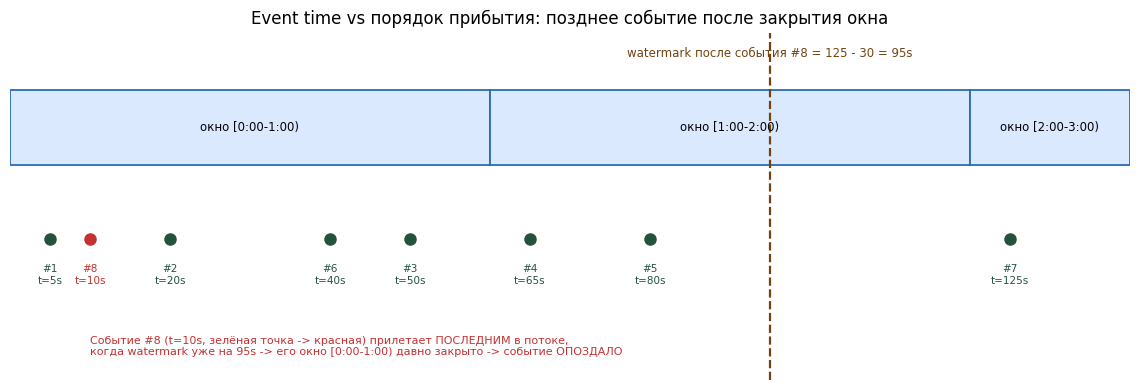

In [6]:
fig, ax = plt.subplots(figsize=(11.5, 4))
ax.set_xlim(0, 140)
ax.set_ylim(0, 4.2)
ax.axis("off")

for w_start, w_end, label in [(0, 60, "окно [0:00-1:00)"), (60, 120, "окно [1:00-2:00)"), (120, 180, "окно [2:00-3:00)")]:
    ax.add_patch(plt.Rectangle((w_start, 2.6), min(w_end, 140) - w_start, 0.9,
                                facecolor="#dbe9ff", edgecolor="#2b6cb0", linewidth=1.3))
    ax.text((w_start + min(w_end, 140)) / 2, 3.05, label, ha="center", va="center", fontsize=8.5)

events = [5, 20, 50, 65, 80, 40, 125, 10]
arrival_order = list(range(1, len(events) + 1))
for order, et in zip(arrival_order, events):
    is_late = (order == 8)
    color = "#c53030" if is_late else "#22543d"
    ax.plot(et, 1.7, "o", color=color, markersize=8)
    ax.annotate(f"#{order}\nt={et}s", (et, 1.7), textcoords="offset points", xytext=(0, -32),
                ha="center", fontsize=7.5, color=color)

ax.axvline(95, color="#744210", linestyle="--", linewidth=1.6)
ax.text(95, 3.9, "watermark после события #8 = 125 - 30 = 95s", color="#744210", fontsize=8.5, ha="center")

ax.text(10, 0.3, "Событие #8 (t=10s, зелёная точка -> красная) прилетает ПОСЛЕДНИМ в потоке,\n"
                  "когда watermark уже на 95s -> его окно [0:00-1:00) давно закрыто -> событие ОПОЗДАЛО",
        fontsize=8, color="#c53030")

ax.set_title("Event time vs порядок прибытия: позднее событие после закрытия окна", fontsize=12)
plt.tight_layout()
plt.show()

### Практика: tumbling window + watermark на реальном Kafka-топике

Смоделируем поток показаний IoT-датчика: несколько событий с `event_time`, часть из них
прилетает **не по порядку** (типичная ситуация — несколько устройств, сетевые задержки).
Окна — по 60 секунд (tumbling, без перекрытия), допустимое опоздание — 30 секунд.

In [13]:
reset_topic("sensor_readings", partitions=1)

base = datetime(2026, 1, 1, 12, 0, 0)
# смещения в секундах от base; порядок В СПИСКЕ = порядок ПРИБЫТИЯ в поток (не время события!)
offsets_sec = [5, 20, 50, 65, 80, 40, 125, 10]

producer2 = KafkaProducer(
    bootstrap_servers=BOOTSTRAP,
    value_serializer=lambda v: json.dumps(v).encode(),
)
for i, off in enumerate(offsets_sec):
    event_time = (base + timedelta(seconds=off)).isoformat()
    producer2.send("sensor_readings", {"reading_id": i, "device_id": "sensor-1",
                                        "event_time": event_time, "value": round(random.uniform(15, 25), 2)})
producer2.flush()
print(f"Отправлено {len(offsets_sec)} показаний, event_time не монотонны (см. offsets_sec)")

Отправлено 8 показаний, event_time не монотонны (см. offsets_sec)


In [14]:
WINDOW = timedelta(seconds=60)
ALLOWED_LATENESS = timedelta(seconds=30)


def window_start(ts: datetime) -> datetime:
    epoch = datetime(1970, 1, 1)
    secs = (ts - epoch).total_seconds()
    win_secs = (secs // WINDOW.total_seconds()) * WINDOW.total_seconds()
    return epoch + timedelta(seconds=win_secs)


consumer3 = KafkaConsumer(
    bootstrap_servers=BOOTSTRAP,
    group_id=f"windowing-{RUN_ID}",
    auto_offset_reset="earliest",
    value_deserializer=lambda v: json.loads(v.decode()),
    consumer_timeout_ms=5000,
)
consumer3.subscribe(["sensor_readings"])

windows: dict[datetime, list[float]] = {}
late_dropped = []
max_event_time = datetime.min

for msg in consumer3:
    event_time = datetime.fromisoformat(msg.value["event_time"])
    max_event_time = max(max_event_time, event_time)
    watermark = max_event_time - ALLOWED_LATENESS

    ws = window_start(event_time)
    we = ws + WINDOW
    if we <= watermark:
        late_dropped.append({"reading_id": msg.value["reading_id"], "event_time": event_time, "window": ws})
        print(f"  ⚠️  reading_id={msg.value['reading_id']} (event_time={event_time.time()}) "
              f"ОПОЗДАЛО: его окно уже закрыто (watermark={watermark.time()})")
        continue
    windows.setdefault(ws, []).append(msg.value["value"])

consumer3.close()

final_watermark = max_event_time - ALLOWED_LATENESS
report_rows = []
for ws, values in sorted(windows.items()):
    we = ws + WINDOW
    status = "CLOSED" if we <= final_watermark else "ещё открыто"
    report_rows.append({"window_start": ws, "window_end": we, "readings_cnt": len(values),
                         "avg_value": round(sum(values) / len(values), 2), "status": status})

windows_report = pd.DataFrame(report_rows)
windows_report

C:\Users\raven\AppData\Local\Temp\ipykernel_27544\1006744368.py:12: DeprecationWarning: value_deserializer does not implement kafka.serializer.Deserializer
  consumer3 = KafkaConsumer(


  ⚠️  reading_id=7 (event_time=12:00:10) ОПОЗДАЛО: его окно уже закрыто (watermark=12:01:35)


,window_start,window_end,readings_cnt,avg_value,status
0,2026-01-01 12:00:00,2026-01-01 12:01:00,4,20.30,CLOSED
1,2026-01-01 12:01:00,2026-01-01 12:02:00,2,19.81,ещё открыто
2,2026-01-01 12:02:00,2026-01-01 12:03:00,1,24.73,ещё открыто


Показание `reading_id=7` (`event_time` — самая первая секунда потока, `t=10s`) прилетело
**последним по порядку прибытия** — к этому моменту watermark уже ушёл далеко вперёд
(благодаря событию с `t=125s`), окно `[0:00, 1:00)` давно закрыто и эмитировано, так что
это показание уже некуда включить — оно отбрасывается (или в реальном движке ушло бы в
отдельный "late data" топик для отдельной обработки). Это именно то, чего вообще не бывает
в batch-мире лекций 1-2: там перед `GROUP BY` уже весь датасет лежит целиком, "опоздать"
физически невозможно.

## 5. От потока к витрине: sink в Postgres

Закроем цепочку "поток → витрина", записав закрытые окна из раздела 4 в ту же Postgres-базу
`pipelines`, что использовалась в [лекции про Airflow](2.ipynb) — по сути, ровно то, чем
занимается **Kafka Connect JDBC Sink** в проде, только руками на 10 строк.

In [15]:
import psycopg2

pg_conn = psycopg2.connect(host="127.0.0.1", port=5433, user="tutor", password="tutor", dbname="pipelines")
pg_conn.autocommit = True
pg_cur = pg_conn.cursor()

pg_cur.execute("DROP TABLE IF EXISTS streaming_window_metrics")
pg_cur.execute("""
CREATE TABLE streaming_window_metrics (
    window_start  TIMESTAMP PRIMARY KEY,
    window_end    TIMESTAMP NOT NULL,
    readings_cnt  INTEGER NOT NULL,
    avg_value     NUMERIC(6,2) NOT NULL
)
""")

closed_windows = windows_report[windows_report["status"] == "CLOSED"]
for row in closed_windows.itertuples(index=False):
    pg_cur.execute(
        "INSERT INTO streaming_window_metrics (window_start, window_end, readings_cnt, avg_value) "
        "VALUES (%s, %s, %s, %s) "
        "ON CONFLICT (window_start) DO UPDATE SET "
        "window_end = EXCLUDED.window_end, readings_cnt = EXCLUDED.readings_cnt, avg_value = EXCLUDED.avg_value",
        (row.window_start, row.window_end, row.readings_cnt, row.avg_value),
    )

print(f"В streaming_window_metrics записано закрытых окон: {len(closed_windows)}")
pd.read_sql("SELECT * FROM streaming_window_metrics ORDER BY window_start", pg_conn)

В streaming_window_metrics записано закрытых окон: 1


C:\Users\raven\AppData\Local\Temp\ipykernel_27544\3558124070.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("SELECT * FROM streaming_window_metrics ORDER BY window_start", pg_conn)


,window_start,window_end,readings_cnt,avg_value
0,2026-01-01 12:00:00,2026-01-01 12:01:00,4,20.3


Открытые окна (`ещё открыто`) сознательно **не** пишем в витрину — записывать неполный
агрегат и потом его "довписывать" по мере закрытия окна — вполне легитимный паттерн
(`UPSERT` тот же самый), но здесь для ясности показываем только то, что уже гарантированно
финализировано.

## 6. CDC (Change Data Capture): как в проде получают потоки без polling

В [лекции 2](2.ipynb) инкрементальная экстракция была устроена так: пайплайн **опрашивает**
(polling) источник по расписанию — `SELECT ... WHERE updated_at > watermark`. У этого подхода
есть два системных недостатка:

1. **Задержка = период опроса.** Если DAG раз в час — событие в среднем "долетит" до DWH
   с задержкой до часа, даже если технически могло попасть туда за секунды.
2. **`DELETE` невидим.** Если строку в источнике удалили, `updated_at > watermark` её просто
   никогда не увидит — она не попадёт в выборку **ни разу**, потому что её больше нет. Polling
   в принципе не может обнаружить удаления без дополнительных ухищрений (soft delete, отдельный
   tombstone-механизм).

**CDC (Change Data Capture)** решает обе проблемы иначе: вместо опроса таблицы читает
**журнал транзакций** самой СУБД (в PostgreSQL — WAL, write-ahead log) и превращает **каждую**
`INSERT`/`UPDATE`/`DELETE` в событие Kafka — почти в реальном времени, без polling вообще.
Самый распространённый инструмент — **Debezium** (коннектор для Kafka Connect). Типичное
CDC-событие выглядит примерно так:

```json
{
  "op": "u",
  "before": {"order_id": 1, "amount": 22.26, "customer_id": 101},
  "after":  {"order_id": 1, "amount": 122.26, "customer_id": 101},
  "source": {"table": "orders", "lsn": 24361648, "ts_ms": 1767700800000},
  "ts_ms": 1767700805123
}
```

`op` — тип операции (`c`=create, `u`=update, `d`=delete, `r`=snapshot-чтение при первом
запуске). Заметьте: `DELETE` здесь отдельная явная операция с `before`, а не "строка молча
исчезла из выборки" — то, чего watermark-polling из лекции 2 в принципе не умеет.

CDC — это ещё и стандартный способ **наполнить Bronze-слой Data Lake** из
[лекции 1](1.ipynb) непрерывно: Debezium → Kafka-топик на таблицу → Kafka Connect S3 Sink →
сырые CDC-события лежат в Bronze почти в реальном времени, а не раз в сутки по батч-ETL.

## 7. Lambda Architecture

Ранний (и до сих пор встречающийся) способ получить и низкую задержку, и корректность
на больших объёмах — **Lambda Architecture** (Nathan Marz, ~2011): данные одновременно
идут в **два независимых** пайплайна:

* **Batch layer** — весь исторический массив данных, пересчитывается периодически (та же
  логика, что в лекциях 1-2), даёт полную точность, но с задержкой
* **Speed layer** — тот же поток обрабатывается потоковым движком (эта лекция), даёт
  приблизительный результат почти сразу, но иногда с погрешностью/дублями
* **Serving layer** — объединяет batch-view (точный, но "вчерашний") и speed-view
  (свежий, но приблизительный) в единый ответ для запросов

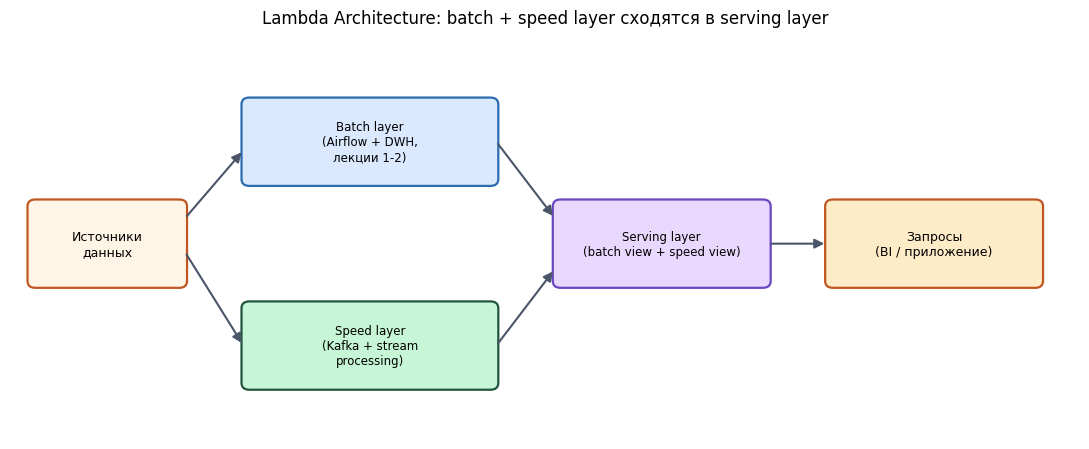

In [10]:
fig, ax = plt.subplots(figsize=(11, 4.6))
ax.set_xlim(0, 11)
ax.set_ylim(0, 4.8)
ax.axis("off")

draw_box(ax, 0.2, 1.8, 1.6, 1.0, "Источники\nданных", facecolor="#fff5e6", edgecolor="#c05621", fontsize=9)

draw_box(ax, 2.4, 3.0, 2.6, 1.0, "Batch layer\n(Airflow + DWH,\nлекции 1-2)", facecolor="#dbe9ff", edgecolor="#2b6cb0", fontsize=8.5)
draw_box(ax, 2.4, 0.6, 2.6, 1.0, "Speed layer\n(Kafka + stream\nprocessing)", facecolor="#c6f6d5", edgecolor="#22543d", fontsize=8.5)
draw_arrow(ax, (1.8, 2.6), (2.4, 3.4))
draw_arrow(ax, (1.8, 2.2), (2.4, 1.1))

draw_box(ax, 5.6, 1.8, 2.2, 1.0, "Serving layer\n(batch view + speed view)", facecolor="#e9d8fd", edgecolor="#6b46c1", fontsize=8.5)
draw_arrow(ax, (5.0, 3.5), (5.6, 2.6))
draw_arrow(ax, (5.0, 1.1), (5.6, 2.0))

draw_box(ax, 8.4, 1.8, 2.2, 1.0, "Запросы\n(BI / приложение)", facecolor="#feebc8", edgecolor="#c05621", fontsize=9)
draw_arrow(ax, (7.8, 2.3), (8.4, 2.3))

ax.set_title("Lambda Architecture: batch + speed layer сходятся в serving layer", fontsize=12)
plt.tight_layout()
plt.show()

**Главная проблема Lambda** — приходится **дважды** реализовывать одну и ту же бизнес-логику:
один раз в batch-коде (SQL/Spark/dbt), второй раз в streaming-коде (Kafka Streams/Flink).
Это не только двойная работа, а источник трудноуловимых багов: логика в двух реализациях
рано или поздно немного разъезжается, и batch-view со speed-view начинают тихо расходиться.

## 8. Kappa Architecture

**Kappa Architecture** (Jay Kreps, один из создателей Kafka, ~2014) — ответ на главную боль
Lambda: а что, если вообще не заводить отдельный batch layer? Всё — единый поток:

* Все данные (включая "исторические") проходят через **один и тот же** streaming-пайплайн
* Если нужно пересчитать историю (нашли баг в логике трансформации, добавили новую метрику) —
  не запускают отдельный batch job, а **replay**: перечитывают журнал Kafka с начала (или с
  нужного offset'а) через **тот же самый** код обработки, что использовался для реального времени
* Для replay нужен достаточно долгий retention в Kafka (или compacted topic — Kafka хранит
  только последнее значение на ключ, а не всю историю событий)

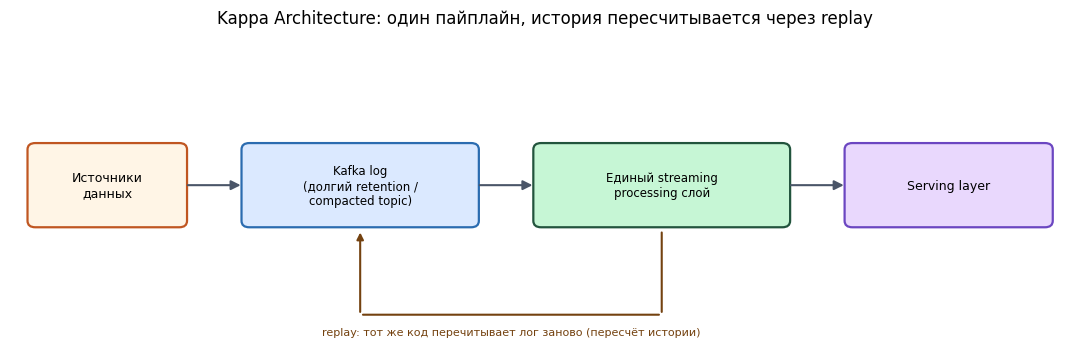

In [11]:
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.set_xlim(0, 11)
ax.set_ylim(0, 3.8)
ax.axis("off")

draw_box(ax, 0.2, 1.4, 1.6, 1.0, "Источники\nданных", facecolor="#fff5e6", edgecolor="#c05621", fontsize=9)
draw_box(ax, 2.4, 1.4, 2.4, 1.0, "Kafka log\n(долгий retention /\ncompacted topic)", facecolor="#dbe9ff", edgecolor="#2b6cb0", fontsize=8.5)
draw_box(ax, 5.4, 1.4, 2.6, 1.0, "Единый streaming\nprocessing слой", facecolor="#c6f6d5", edgecolor="#22543d", fontsize=8.5)
draw_box(ax, 8.6, 1.4, 2.1, 1.0, "Serving layer", facecolor="#e9d8fd", edgecolor="#6b46c1", fontsize=9)

draw_arrow(ax, (1.8, 1.9), (2.4, 1.9))
draw_arrow(ax, (4.8, 1.9), (5.4, 1.9))
draw_arrow(ax, (8.0, 1.9), (8.6, 1.9))

ax.annotate("", xy=(6.7, 1.35), xytext=(6.7, 0.3),
            arrowprops=dict(arrowstyle="-", color="#744210", linewidth=1.5))
ax.annotate("", xy=(3.6, 0.3), xytext=(6.7, 0.3),
            arrowprops=dict(arrowstyle="-", color="#744210", linewidth=1.5))
ax.annotate("", xy=(3.6, 1.35), xytext=(3.6, 0.3),
            arrowprops=dict(arrowstyle="-|>", color="#744210", linewidth=1.5))
ax.text(5.15, 0.05, "replay: тот же код перечитывает лог заново (пересчёт истории)",
        fontsize=8, color="#744210", ha="center")

ax.set_title("Kappa Architecture: один пайплайн, история пересчитывается через replay", fontsize=12)
plt.tight_layout()
plt.show()

| | Lambda | Kappa |
|---|---|---|
| Кодовых баз для одной логики | 2 (batch + streaming) | 1 (только streaming) |
| Риск расхождения batch/speed view | Есть (два независимых кода) | Нет (один и тот же код) |
| Пересчёт истории | Отдельный batch job | Replay того же пайплайна |
| Требования к хранилищу | Обычное (batch слой хранит всё) | Нужен длинный retention/compaction в Kafka |
| Когда оправдано | Много сложной batch-аналитики, для которой streaming-эквивалента просто нет | Логика реально одна и та же для истории и реального времени |

На практике чистая Kappa встречается реже, чем можно подумать — многие компании держат
Lakehouse (лекция 1) как "источник истины" для тяжёлой аналитики именно потому, что не вся
логика хорошо ложится на потоковую модель (сложные многошаговые джойны, ML-фичи на полной
истории) — и получается гибрид, где Kappa покрывает real-time метрики, а Lakehouse — глубокую
аналитику, без формального деления на "batch layer" и "speed layer" в духе классической Lambda.

## 9. Инструменты в реальном мире

| Категория | Примеры |
|---|---|
| Брокеры сообщений | Apache Kafka, Redpanda, AWS Kinesis, Google Pub/Sub, Azure Event Hubs |
| CDC | Debezium, AWS DMS, Fivetran (managed CDC) |
| Потоковая обработка | Apache Flink, Kafka Streams, ksqlDB, Spark Structured Streaming |
| Коннекторы (sink/source) | Kafka Connect + коннекторы (JDBC, S3, Elasticsearch, Snowflake) |
| Управляемые платформы | Confluent Cloud, AWS MSK, Redpanda Cloud |

Частая продакшн-связка: **Postgres (WAL) → Debezium → Kafka → Flink/ksqlDB (агрегации,
обогащение) → Kafka Connect S3/JDBC Sink → Bronze-слой Data Lake / DWH из лекции 1**.

## 10. Batch vs Streaming: как выбирать

Streaming — это ощутимо больше операционной сложности (нужно поддерживать брокер, следить
за consumer lag, продумывать идемпотентность на каждом шаге), поэтому важно не тащить его
туда, где он не нужен:

* **Отчёт для менеджеров раз в день, дашборд обновляется по утрам** → обычный batch
  (Airflow + DWH из лекций 1-2) — streaming здесь чистые накладные расходы без пользы
* **Нужна свежесть в пределах часа-нескольких** → чаще всего **микро-batch** (частый Airflow
  DAG каждые 5-15 минут) — то же самое, что и streaming по ощущениям пользователя, но
  на порядок проще в эксплуатации
* **Секунды принципиально важны** (детекция мошенничества в момент оплаты, алерты по
  метрикам инфраструктуры, персонализация в реальном времени) → нужен реальный streaming
* **Нужно видеть и `DELETE`, и `UPDATE` из источника, а не только новые строки** → CDC,
  независимо от того, нужна ли вам итоговая свежесть в реальном времени

Хорошее эмпирическое правило: начинать с batch/микро-batch и переходить на настоящий
streaming только тогда, когда конкретное бизнес-требование к задержке (не "было бы неплохо",
а измеримое SLA) физически недостижимо через batch.

## 11. Важные выводы

👉 **Партиция** — единица параллелизма и упорядоченности в Kafka; порядок гарантирован
только *внутри* партиции, поэтому ключ партиционирования выбирают исходя из того, для какой
сущности порядок событий критичен.

👉 **At-least-once** (обработать → закоммитить offset) — стандартный компромисс на практике;
дубли лечатся идемпотентной записью в приёмник (`UPSERT`), а не попыткой достичь "настоящего"
exactly-once через весь стек.

👉 **Watermark в streaming** (event time минус допустимое опоздание) — отдельное понятие от
watermark в batch-ETL (лекция 2); оба решают вопрос "когда данные точно все", но на разных
уровнях: там — какая часть таблицы уже загружена, здесь — можно ли закрыть временное окно.

👉 **CDC** снимает системные ограничения polling-экстракции из лекции 2: не теряет `DELETE`,
не привязан к периоду опроса — но требует доступа к журналу транзакций источника.

👉 **Lambda** = два независимых пайплайна (batch + speed) для одной логики → риск расхождения.
**Kappa** = один пайплайн, история пересчитывается через replay лога → нужен долгий retention.

👉 Streaming — это компромисс: более низкая задержка ценой заметно большей операционной
сложности. Разумный дефолт — batch/микро-batch, пока измеримое SLA явно не требует иного.

## 12. Задания для практики

1. Модифицируйте демонстрацию из раздела 3 так, чтобы вместо простого множества дублей
   (`set(processed_run1) & set(processed_run2)`) вести идемпотентную запись в Python-словарь
   `order_id -> amount` (аналог `UPSERT`), и убедитесь, что после "прогона 2" в словаре нет
   искажений данных, несмотря на повторную обработку.
2. Добавьте в раздел 4 side-output: вместо того чтобы просто печатать опоздавшие события,
   собирайте их в отдельный список/DataFrame `late_events_report` и посчитайте, какую долю
   от общего числа событий они составили.
3. Уменьшите `ALLOWED_LATENESS` до 5 секунд в разделе 4 и прогоните пайплайн заново — сколько
   событий теперь попадёт в "опоздавшие"? Объясните на пальцах компромисс: чем меньше
   allowed lateness, тем быстрее закрываются окна (ниже latency), но тем больше реальных,
   просто немного задержавшихся событий будет теряться.
4. Опишите (без кода, в markdown) гипотетический Kappa-пайплайн для интернет-магазина:
   какие события идут в Kafka, какой стриминговый слой их обрабатывает, и как бы выглядел
   replay при обнаружении бага в подсчёте выручки за прошлый месяц.